In [2]:
import numpy as np
import cv2
import librosa
import matplotlib.pyplot as plt
import os

def to_uint8(arr):
    mn, mx = arr.min(), arr.max()
    if mx == mn:
        return np.zeros(arr.shape, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)

src_file = r"c:\Users\Miguel\Desktop\EstudosUTFPR\WikiAvesModel\dataset\bacurau\bacurau_33.npy"

S = np.load(src_file)
imagem_origina = to_uint8(S)


Text(0, 0.5, 'Mel Bin')

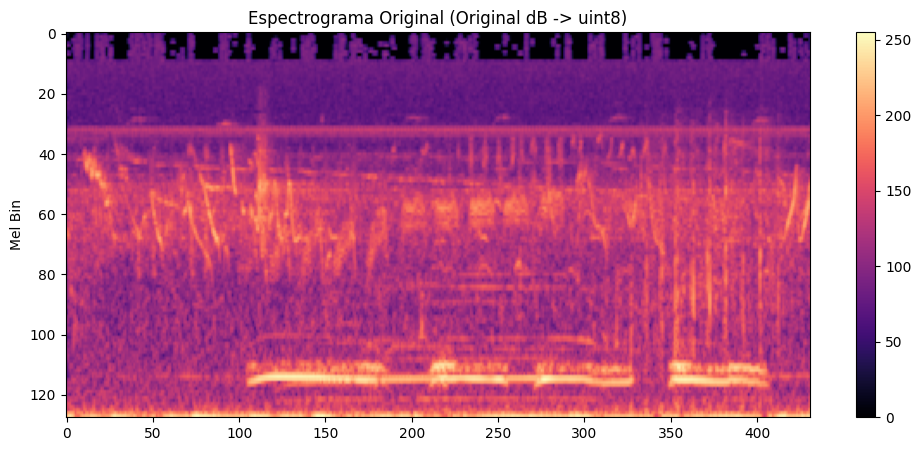

In [86]:
plt.figure(figsize=(12, 5))
plt.title("Espectrograma Original (Original dB -> uint8)")
plt.imshow(np.flipud(imagem_origina), aspect='auto', cmap='magma')
plt.colorbar()
plt.ylabel('Mel Bin')

Text(0, 0.5, 'Mel Bin')

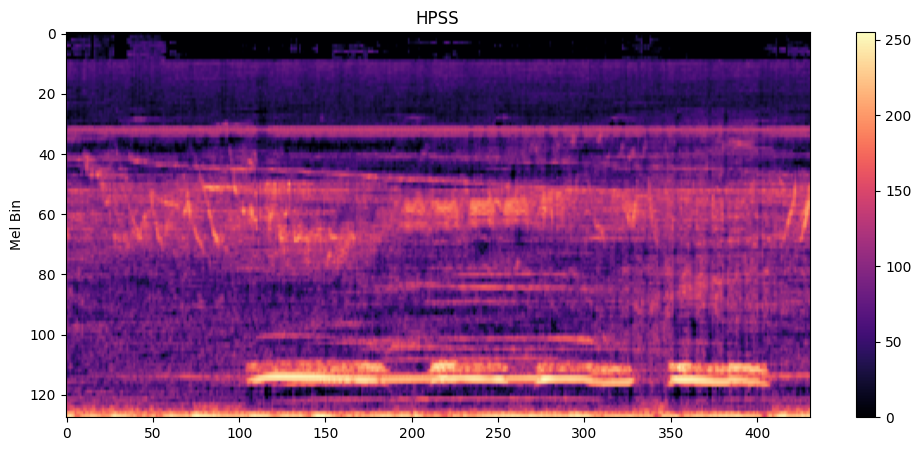

In [87]:

Espec_power = librosa.db_to_power(S)
Espec_harmonic, _ = librosa.decompose.hpss(Espec_power, margin=3.0)
Espec_harm_db = librosa.power_to_db(Espec_harmonic, ref=Espec_power.max())
imagem_hpss = to_uint8(Espec_harm_db)

plt.figure(figsize=(12, 5))
plt.title("HPSS")
plt.imshow(np.flipud(imagem_hpss), aspect='auto', cmap='magma')
plt.colorbar()
plt.ylabel('Mel Bin')

Text(0, 0.5, 'Mel Bin')

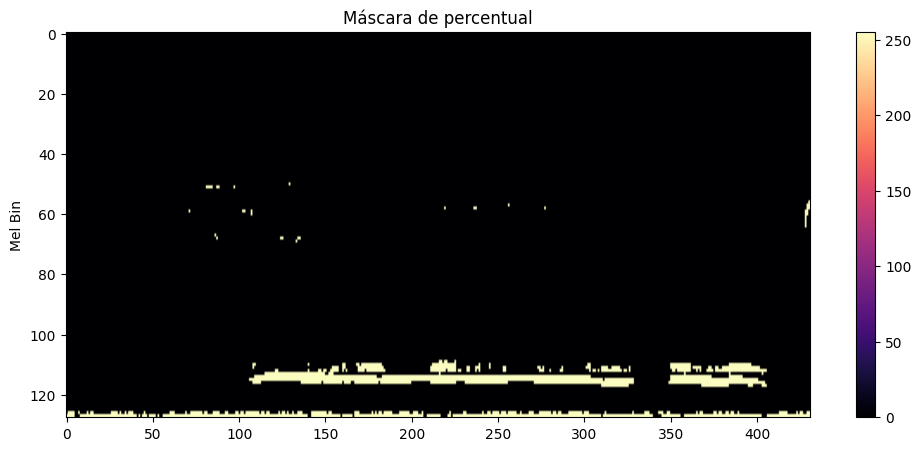

In [88]:

thresh_val = np.percentile(imagem_hpss, 97)
binary = (imagem_hpss >= thresh_val).astype(np.uint8) * 255

plt.figure(figsize=(12, 5))
plt.title("Máscara de percentual")
plt.imshow(np.flipud(binary), aspect='auto', cmap='magma')
plt.colorbar()
plt.ylabel('Mel Bin')

Text(0, 0.5, 'Mel Bin')

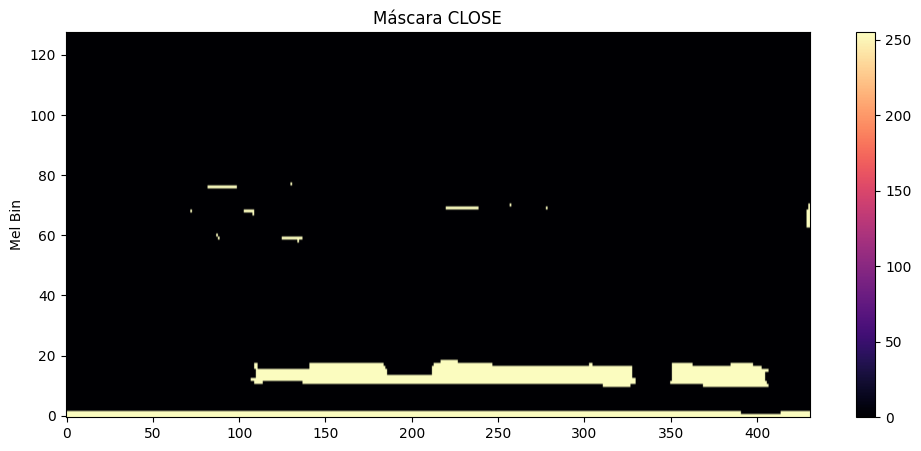

In [89]:
kc = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 3))
mask = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kc)

plt.figure(figsize=(12, 5))
plt.title("Máscara CLOSE")
plt.imshow(mask, aspect='auto', cmap='magma', origin='lower')
plt.colorbar()
plt.ylabel('Mel Bin')

Text(0, 0.5, 'Mel Bin')

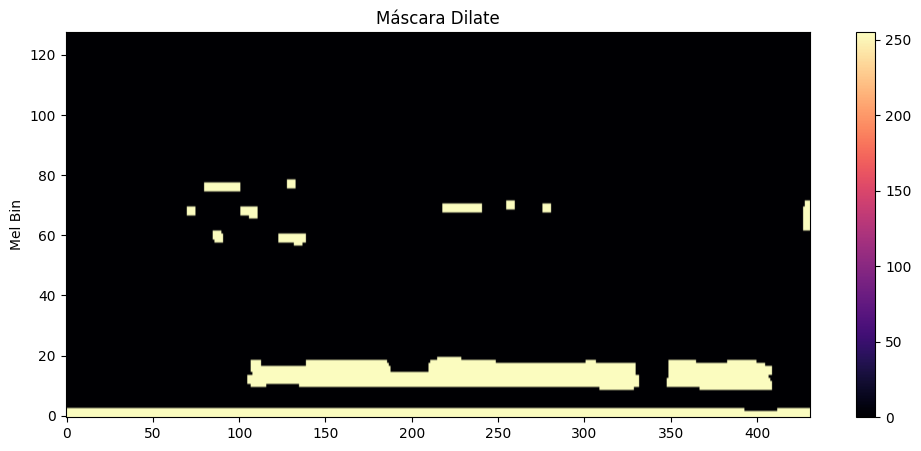

In [90]:
kd = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3))
mask = cv2.dilate(mask, kd, iterations=1)

plt.figure(figsize=(12, 5))
plt.title("Máscara Dilate")
plt.imshow(mask, aspect='auto', cmap='magma', origin='lower')
plt.colorbar()
plt.ylabel('Mel Bin')

Text(0, 0.5, 'Mel Bin')

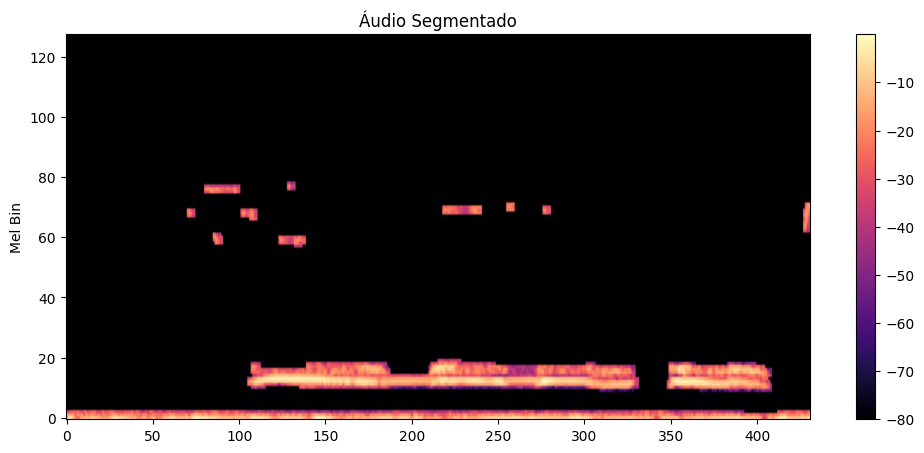

In [91]:
n_labels, _, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
segs = []
for lbl in range(1, n_labels):
    x    = stats[lbl, cv2.CC_STAT_LEFT]
    w    = stats[lbl, cv2.CC_STAT_WIDTH]
    area = stats[lbl, cv2.CC_STAT_AREA]
    if area >= 100 and w >= 10:
        segs.append((x, x + w))

segs.sort()
merged = []
for x1, x2 in segs:
    if merged and x1 <= merged[-1][1] + 20:
        merged[-1] = (merged[-1][0], max(merged[-1][1], x2))
    else:
        merged.append((x1, x2))

mask_float = (mask / 255.0).astype(np.float32)
Espec_seg = np.where(mask_float > 0.5, Espec_harm_db, S.min())

plt.figure(figsize=(12, 5))
plt.title("Áudio Segmentado")
plt.imshow(Espec_seg, aspect='auto', cmap='magma', origin='lower')
plt.colorbar()
plt.ylabel('Mel Bin')
